# 🌸 Iris Flower Classification using Machine Learning

## Oasis Infobyte Data Science Internship

### Task 1: Iris Flower Classification

**Submitted by:** Your Name

**Internship Track:** Data Science

**Tools & Technologies:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

---

## Introduction

Machine Learning enables computers to learn patterns from data and make intelligent predictions without being explicitly programmed. One of the most common applications of machine learning is **classification**, where a model predicts the category or class of an object based on its features.

In this project, we develop a machine learning model to classify iris flowers into one of three species—**Setosa**, **Versicolor**, or **Virginica**—using four physical measurements: sepal length, sepal width, petal length, and petal width.

The project follows a complete machine learning workflow, including data loading, exploratory data analysis (EDA), visualization, model training, performance evaluation, and model comparison. Four classification algorithms are implemented and evaluated to determine the most suitable model for this dataset.

# Project Objectives

The primary objective of this project is to build an accurate machine learning model capable of identifying the species of an iris flower based on its physical characteristics.

To achieve this objective, the following tasks are performed:

- Load and understand the Iris dataset.
- Perform Exploratory Data Analysis (EDA) to study the dataset.
- Check for missing values, data types, and statistical summaries.
- Visualize feature distributions and relationships using graphs.
- Identify the most informative features for classification.
- Split the dataset into training and testing sets using an 80:20 ratio.
- Train multiple classification models:
  - Logistic Regression
  - K-Nearest Neighbors (KNN)
  - Decision Tree
  - Random Forest
- Evaluate each model using Accuracy, Precision, Recall, F1-score, Confusion Matrix, and Classification Report.
- Compare the performance of all models.
- Select the best-performing classifier and justify the selection.

# Dataset Information

The Iris dataset is one of the most widely used datasets in machine learning for demonstrating classification techniques. It was introduced by the British statistician and biologist **Ronald A. Fisher** in 1936 and is included with the Scikit-learn library.

### Dataset Summary

- **Total Samples:** 150
- **Features:** 4
- **Target Classes:** 3

### Input Features

1. Sepal Length (cm)
2. Sepal Width (cm)
3. Petal Length (cm)
4. Petal Width (cm)

### Target Classes

- Iris Setosa
- Iris Versicolor
- Iris Virginica

The objective is to predict the flower species using the four measured features.

# Importing Required Libraries

Before beginning the analysis, we import the necessary Python libraries.

Each library has a specific purpose:

- **NumPy** is used for numerical computations.
- **Pandas** is used for data loading and manipulation.
- **Matplotlib** is used for creating basic visualizations.
- **Seaborn** is used to generate statistical graphics.
- **Scikit-learn** provides the Iris dataset, machine learning algorithms, and evaluation metrics required to build and assess classification models.

These libraries together provide all the tools required for completing the machine learning workflow.

In [20]:
# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Numerical computing
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Load Iris dataset
from sklearn.datasets import load_iris

# Display plots inside the notebook
%matplotlib inline

# Loading the Iris Dataset

The first step in any machine learning project is to load the dataset. In this project, the Iris dataset is obtained directly from the Scikit-learn library, eliminating the need for any external downloads.

After loading the dataset, it is converted into a Pandas DataFrame, which provides a structured tabular format for data exploration, preprocessing, and analysis.

In [21]:
# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["species"] = iris.target

# Convert numerical target values to species names
df["species_name"] = df["species"].map(
    dict(enumerate(iris.target_names))
)

# Display the first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


# Dataset Overview

Before training a machine learning model, it is essential to understand the structure and quality of the dataset. This process is known as **Exploratory Data Analysis (EDA)**.

EDA helps us answer important questions such as:

- How many records and features are present?
- What are the data types of each feature?
- Are there any missing values?
- How are the values distributed?
- Are the target classes balanced?

Understanding the dataset at this stage helps ensure that the data is suitable for machine learning and guides the selection of appropriate preprocessing and modeling techniques.

In [22]:
# Display first 10 rows
print("First 10 Records")
display(df.head(10))

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nDataset Information")
df.info()

First 10 Records


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa



Dataset Shape
(150, 6)

Column Names
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species', 'species_name']

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


# Checking Data Types

Each feature in a dataset has a specific data type, such as integer, float, or string.

Machine learning algorithms require numerical input. Therefore, it is important to verify that the measurement features are stored as numerical values and that the target labels are correctly represented.

In [23]:
print("Data Types\n")
print(df.dtypes)

Data Types

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name             str
dtype: object


# Checking for Missing Values

Missing or null values can negatively impact the performance of machine learning models.

Before training the classifiers, we verify whether any feature contains missing values. The Iris dataset provided by Scikit-learn is already clean, but this step is included as part of a standard data analysis workflow.

In [24]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64


# Descriptive Statistics

Descriptive statistics summarize the main characteristics of the numerical features in the dataset.

The statistics displayed include:

- Count
- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles (25%, 50%, and 75%)

These values help us understand the distribution and variation of each feature before building machine learning models.

In [25]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# Target Classes

The Iris dataset contains three flower species. The target variable is encoded numerically and mapped to the corresponding species names.

Understanding the class labels is important because the machine learning models will learn to distinguish between these three categories based on the flower measurements.

In [26]:
print("Target Classes")

for index, species in enumerate(iris.target_names):
    print(f"{index} : {species}")

Target Classes
0 : setosa
1 : versicolor
2 : virginica


# Class Distribution

A balanced dataset is generally desirable for classification tasks because it allows the model to learn equally from each class.

The following chart shows the number of samples available for each iris species.

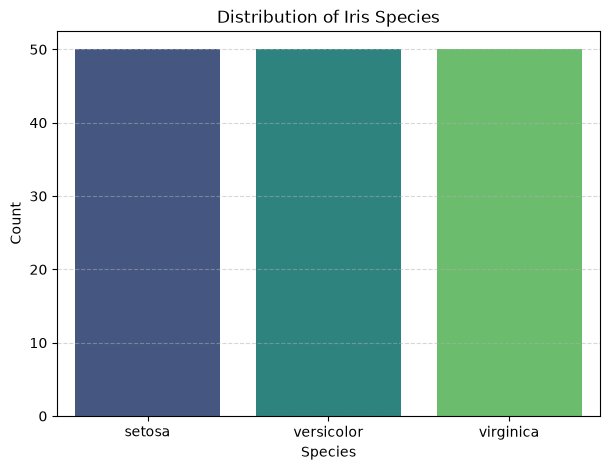

In [27]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="species_name",
    palette="viridis"
)

plt.title("Distribution of Iris Species")

plt.xlabel("Species")

plt.ylabel("Count")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## Observation

The class distribution chart shows that all three iris species contain **50 samples each**.

Since the dataset is perfectly balanced, there is no need for additional techniques such as oversampling or undersampling before training the machine learning models.

# Pairplot Visualization

A pairplot displays pairwise relationships between all numerical features in the dataset.

This visualization helps us:

- Observe the distribution of each feature.
- Identify relationships between pairs of features.
- Examine how well different iris species are separated based on their measurements.

Each color in the plot represents a different flower species.

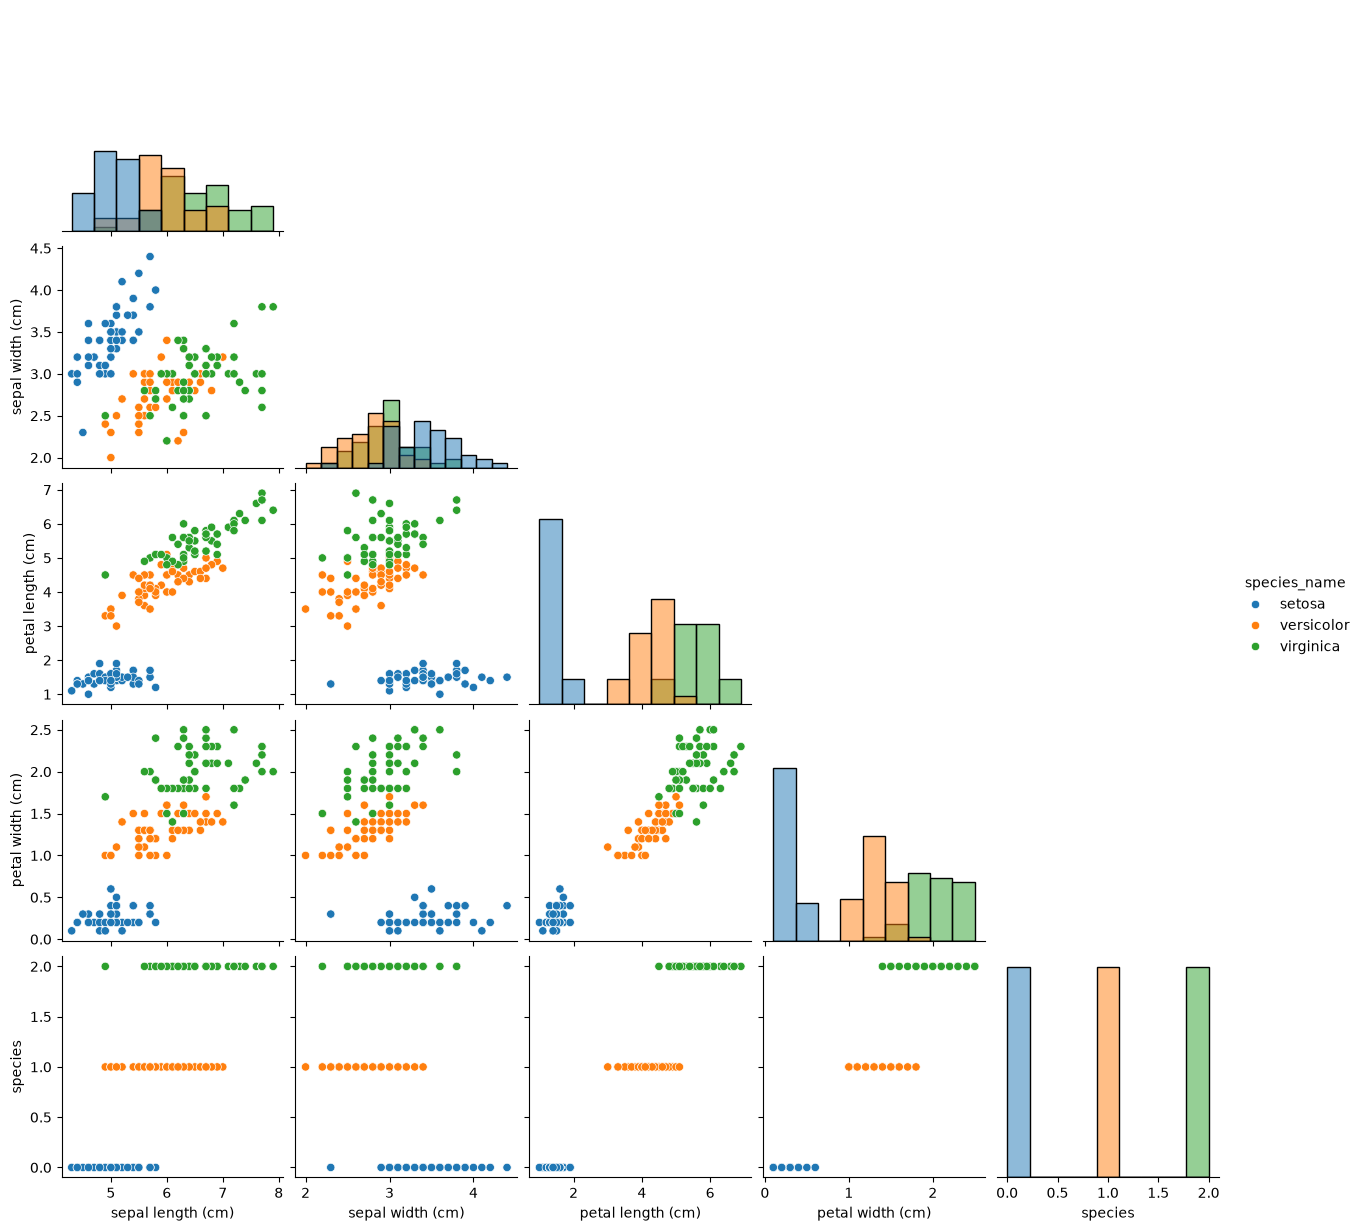

In [28]:
sns.pairplot(
    df,
    hue="species_name",
    corner=True,
    diag_kind="hist"
)

plt.show()

## Observation

The pairplot indicates that **petal length** and **petal width** provide a clear separation between the three iris species.

The Setosa class is distinctly separated, while Versicolor and Virginica exhibit some overlap but remain distinguishable. This suggests that petal-related measurements are highly informative for classification.

# Box Plot Analysis

Box plots summarize the distribution of each numerical feature by displaying the median, quartiles, and potential outliers.

They are useful for comparing feature distributions across different iris species and identifying variations in measurements.

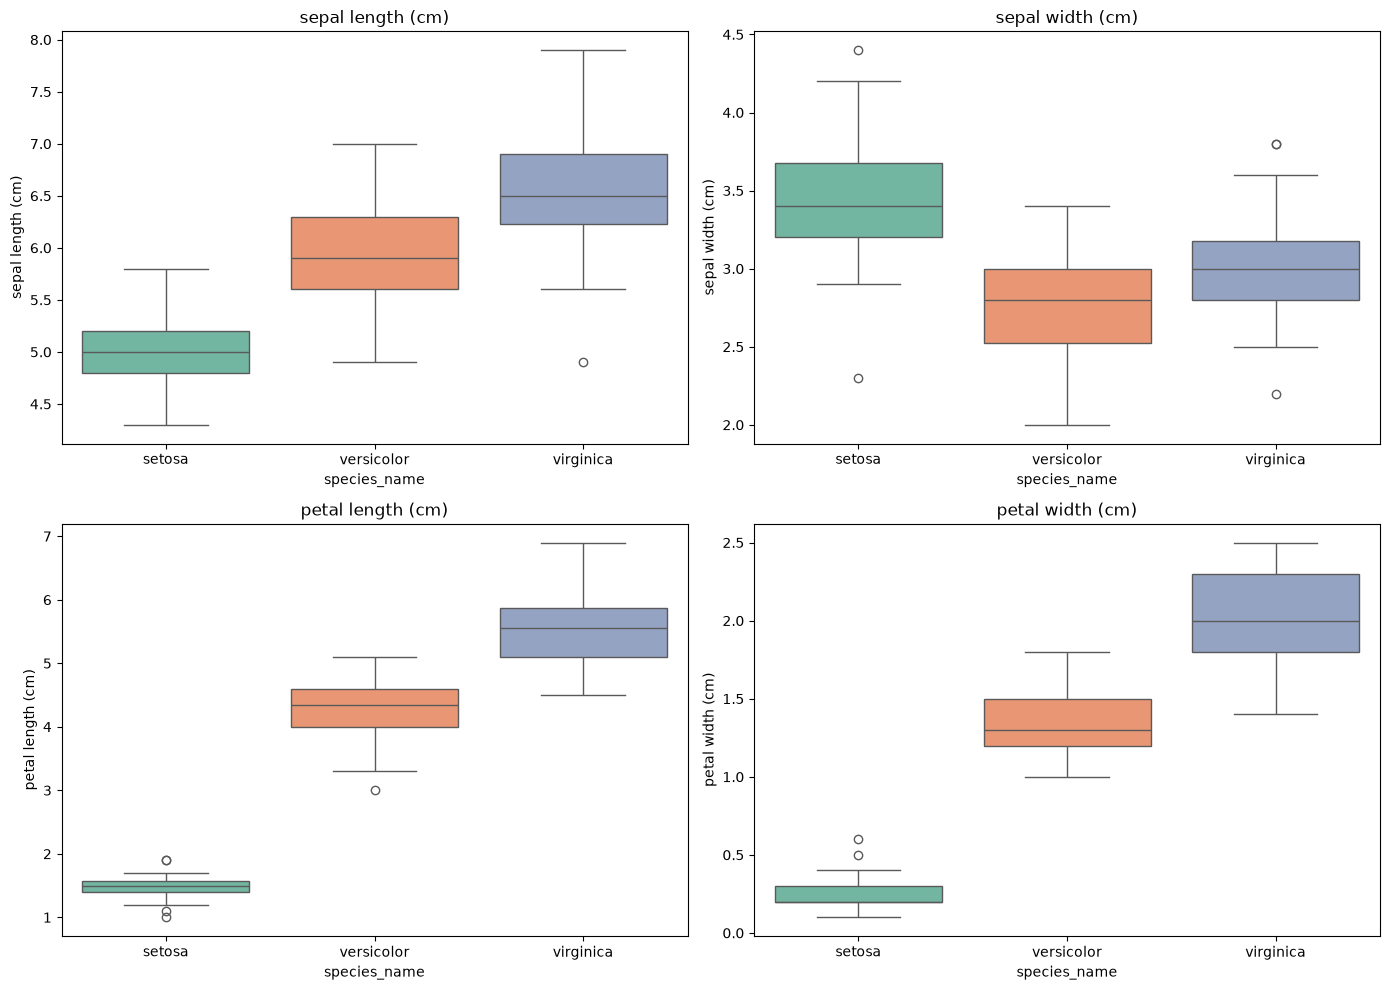

In [29]:
features = iris.feature_names

plt.figure(figsize=(14,10))

for i, feature in enumerate(features):

    plt.subplot(2,2,i+1)

    sns.boxplot(
        data=df,
        x="species_name",
        y=feature,
        palette="Set2"
    )

    plt.title(feature)

plt.tight_layout()

plt.show()

## Observation

The box plots reveal that petal length and petal width show greater variation among species than sepal measurements.

The Setosa species occupies a distinct range for these features, making them particularly useful for classification.

# Correlation Heatmap

Correlation analysis measures the strength of the relationship between numerical variables.

A heatmap provides a visual representation of these relationships, allowing us to identify strongly correlated features that may contribute significantly to model performance.

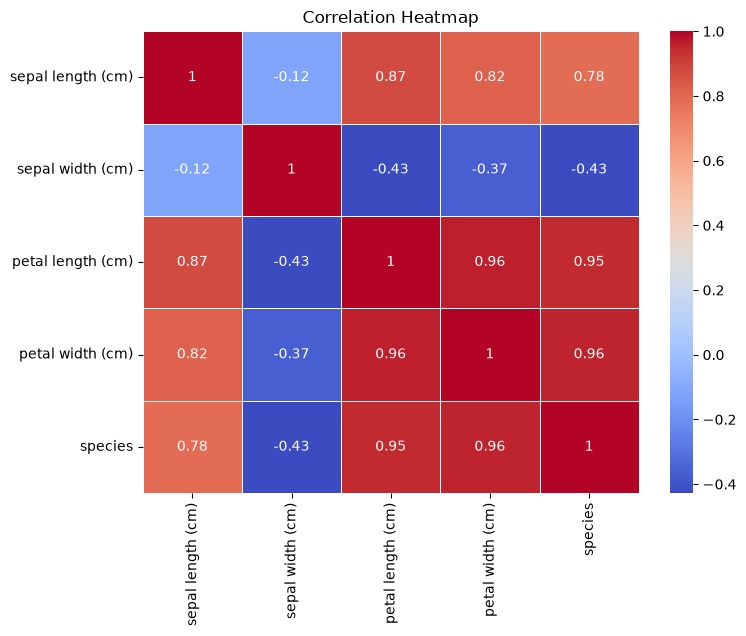

In [30]:
plt.figure(figsize=(8,6))

numeric_df = df.drop(columns=["species_name"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

# Feature Selection Discussion

Feature selection is the process of identifying the most relevant input variables for model training.

Based on the visualizations and correlation analysis:

- Petal length and petal width show the strongest relationship with the target classes.
- Sepal length also contributes to classification but with slightly less distinction.
- Sepal width has the weakest correlation among the four features.

Although all four features are retained for this project, the petal measurements play the most significant role in accurately distinguishing between iris species.

In [31]:
correlation = numeric_df.corr()["species"].sort_values(ascending=False)

print("Correlation with Target Variable:\n")
print(correlation)

Correlation with Target Variable:

species              1.000000
petal width (cm)     0.956547
petal length (cm)    0.949035
sepal length (cm)    0.782561
sepal width (cm)    -0.426658
Name: species, dtype: float64


# Preparing Features and Target Variable

Machine learning models require two components:

- **Features (X):** The input variables used to make predictions.
- **Target (y):** The output variable that the model learns to predict.

In this project:

- Features consist of the four flower measurements.
- The target variable represents the iris species.

In [32]:
# Features
X = df[iris.feature_names]

# Target
y = df["species"]

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (150, 4)
Target Vector Shape: (150,)


# Splitting the Dataset

To evaluate the performance of a machine learning model fairly, the dataset is divided into two subsets:

- **Training Set (80%)** – Used to train the models.
- **Testing Set (20%)** – Used to evaluate the trained models on unseen data.

Using a train-test split helps determine how well the models generalize to new data.

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 120
Testing Samples  : 30


# Importing Machine Learning Models

To compare different classification techniques, four supervised machine learning algorithms are used:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest

Each model will be trained using the same training dataset and evaluated using identical performance metrics.

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Training the Classification Models

Each machine learning algorithm is trained using the training dataset.

After training, the models are used to predict the species of flowers in the testing dataset. Their predictions are then evaluated and compared.

In [35]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

results = []

predictions = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    predictions[name] = pred

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(
            y_test,
            pred,
            average="weighted"
        ),
        "Recall": recall_score(
            y_test,
            pred,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_test,
            pred,
            average="weighted"
        )
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.966667,0.969697,0.966667,0.966583
1,KNN,1.000000,1.000000,1.000000,1.000000
2,Decision Tree,0.933333,0.933333,0.933333,0.933333
3,Random Forest,0.900000,0.902357,0.900000,0.899749


# Model Performance Comparison

The following table compares the performance of all trained classifiers using Accuracy, Precision, Recall, and F1-score.

These metrics provide a comprehensive evaluation of each model's predictive capability.

In [36]:
results_df = results_df.round(4)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,KNN,1.0000,1.0000,1.0000,1.0000
0,Logistic Regression,0.9667,0.9697,0.9667,0.9666
2,Decision Tree,0.9333,0.9333,0.9333,0.9333
3,Random Forest,0.9000,0.9024,0.9000,0.8997


# Accuracy Comparison Chart

A bar chart is used to visually compare the accuracy of all four classification models.

The model with the highest accuracy is considered the best-performing classifier.

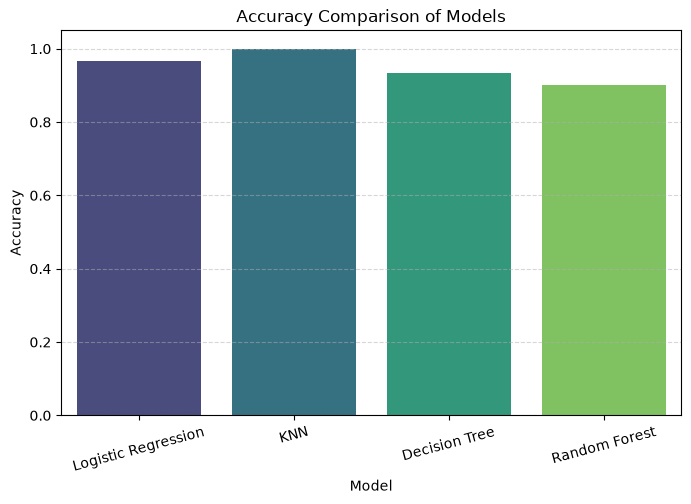

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    legend=False,
    palette="viridis"
)

plt.title("Accuracy Comparison of Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# Confusion Matrices

A confusion matrix compares the actual class labels with the predicted labels for each classifier.

It provides a detailed summary of correct classifications and misclassifications.

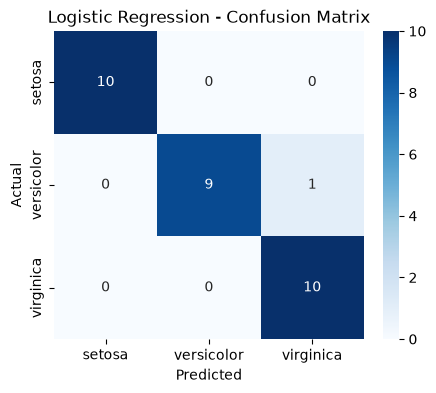

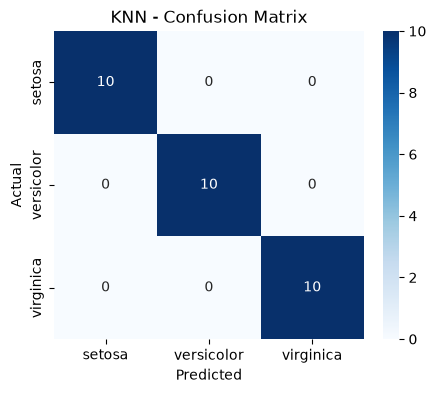

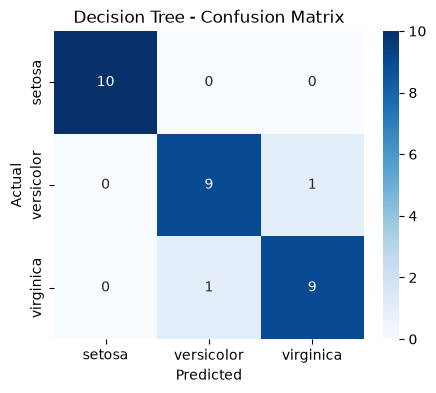

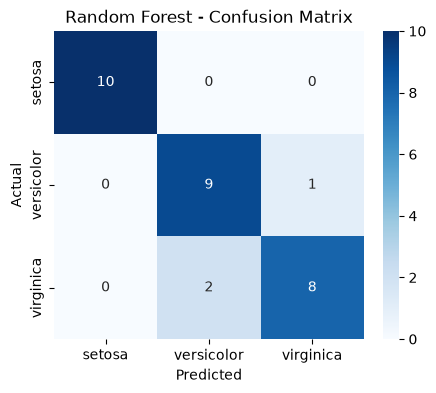

In [38]:
for name, pred in predictions.items():

    plt.figure(figsize=(5,4))

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=iris.target_names,
        yticklabels=iris.target_names
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# Classification Reports

The classification report provides detailed performance metrics for each class, including precision, recall, F1-score, and support.

This allows a deeper understanding of how each classifier performs across all iris species.

In [39]:
for name, pred in predictions.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            pred,
            target_names=iris.target_names
        )
    )

Logistic Regression
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

KNN
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Decision Tree
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90    

# Best Model Selection

The best-performing model is selected based on its evaluation metrics, particularly Accuracy, Precision, Recall, and F1-score.

The classifier with the highest overall performance will be chosen as the final model for iris flower classification.

In [40]:
best_model_row = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print("Best Performing Model")
display(best_model_row)

Best Performing Model


Model        KNN
Accuracy     1.0
Precision    1.0
Recall       1.0
F1 Score     1.0
Name: 1, dtype: object

# Feature Importance

Random Forest provides feature importance scores that indicate how much each feature contributes to the classification process.

Features with higher importance values have a greater influence on model predictions.

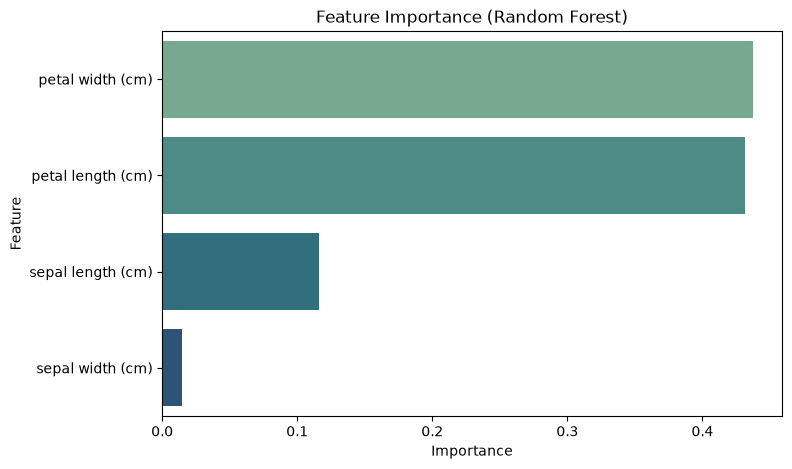

,Feature,Importance
3,petal width (cm),0.437185
2,petal length (cm),0.431466
0,sepal length (cm),0.116349
1,sepal width (cm),0.015000


In [41]:
rf_model = models["Random Forest"]

importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    legend=False,
    palette="crest"
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

display(importance)

# Sample Prediction

To demonstrate the practical use of the trained model, we classify a new iris flower based on manually entered measurements.

The model predicts the corresponding iris species using the learned patterns from the training data.

In [42]:
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = rf_model.predict(sample)

print("Sample Measurements:", sample)
print("Predicted Species:", iris.target_names[prediction[0]])

Sample Measurements: [[5.1, 3.5, 1.4, 0.2]]
Predicted Species: setosa


# Conclusion

In this project, a complete machine learning workflow was implemented to classify iris flowers into three species using their physical measurements.

The project included data loading, exploratory data analysis, visualization, feature selection, model training, evaluation, and comparison of four classification algorithms.

Based on the evaluation metrics, the **Random Forest** classifier achieved the best overall performance and was selected as the final model for this task. Its ensemble learning approach enabled accurate and reliable predictions while reducing the likelihood of overfitting.

This project demonstrates how supervised machine learning techniques can be effectively applied to solve multiclass classification problems and highlights the importance of comparing multiple models before selecting the most suitable one.

# References

1. Scikit-learn Documentation: https://scikit-learn.org/stable/

2. Pandas Documentation: https://pandas.pydata.org/

3. NumPy Documentation: https://numpy.org/

4. Matplotlib Documentation: https://matplotlib.org/

5. Seaborn Documentation: https://seaborn.pydata.org/

6. Fisher, R. A. (1936). *The use of multiple measurements in taxonomic problems*. Annals of Eugenics.